### Tasks

* 1. Given a small dataset of 6 food delivery orders (with features like delivery_time and distance), manually create the initial distance matrix using the Euclidean distance formula between each pair of orders.<br><br><em><strong>Hint:</strong> Use the formula sqrt((x2 - x1)^2 + (y2 - y1)^2) for each pair.</em>

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
orders = np.array([
    [15, 2.5], [20, 3.0], [45, 8.0], 
    [10, 1.5], [50, 9.5], [25, 4.0]
])

In [38]:
n = len(orders)
dist_matrix = np.zeros((n, n))

In [ ]:
for i in range(n):
    for j in range(n):
        x1, y1 = orders[i]
        x2, y2 = orders[j]
        # Formula: sqrt((x2 - x1)^2 + (y2 - y1)^2)
        dist_matrix[i][j] = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

In [40]:
df_matrix = pd.DataFrame(np.round(dist_matrix, 2), 
                         columns=[f"Order {i+1}" for i in range(n)], 
                         index=[f"Order {i+1}" for i in range(n)])
print("Initial Distance Matrix:")
display(df_matrix)

Initial Distance Matrix:


,Order 1,Order 2,Order 3,Order 4,Order 5,Order 6
Order 1,0.00,5.02,30.50,5.10,35.69,10.11
Order 2,5.02,0.00,25.50,10.11,30.70,5.10
Order 3,30.50,25.50,0.00,35.60,5.22,20.40
Order 4,5.10,10.11,35.60,0.00,40.79,15.21
Order 5,35.69,30.70,5.22,40.79,0.00,25.60
Order 6,10.11,5.10,20.40,15.21,25.60,0.00


* 2. Using Python and sklearn, perform agglomerative hierarchical clustering on a dataset of 8 songs (with features like tempo and energy), and plot the resulting dendrogram using scipy's dendrogram function.

In [41]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [42]:
songs = np.array([
    [120, 8.5], [122, 8.2], [75, 3.1], [78, 3.5], 
    [128, 9.0], [130, 9.2], [80, 4.0], [82, 4.2]
])

In [43]:
song_labels = [f"Song {i+1}" for i in range(len(songs))]

In [44]:
model = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = model.fit_predict(songs)

In [45]:
linked_single = linkage(songs, method='single')

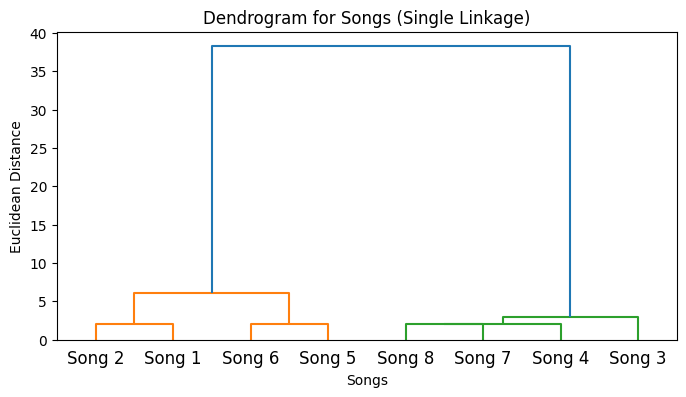

In [46]:
plt.figure(figsize=(8, 4))
dendrogram(linked_single, labels=song_labels, orientation='top', 
           distance_sort='descending', show_leaf_counts=True)
plt.title("Dendrogram for Songs (Single Linkage)")
plt.xlabel("Songs")
plt.ylabel("Euclidean Distance")
plt.show()

* 3. Change the linkage method in your clustering code from 'single' to 'complete' and 'average', and observe how the dendrogram structure changes for your songs dataset.<br><br><em><strong>Hint:</strong> Use the linkage parameter in AgglomerativeClustering or scipy's linkage function.</em>

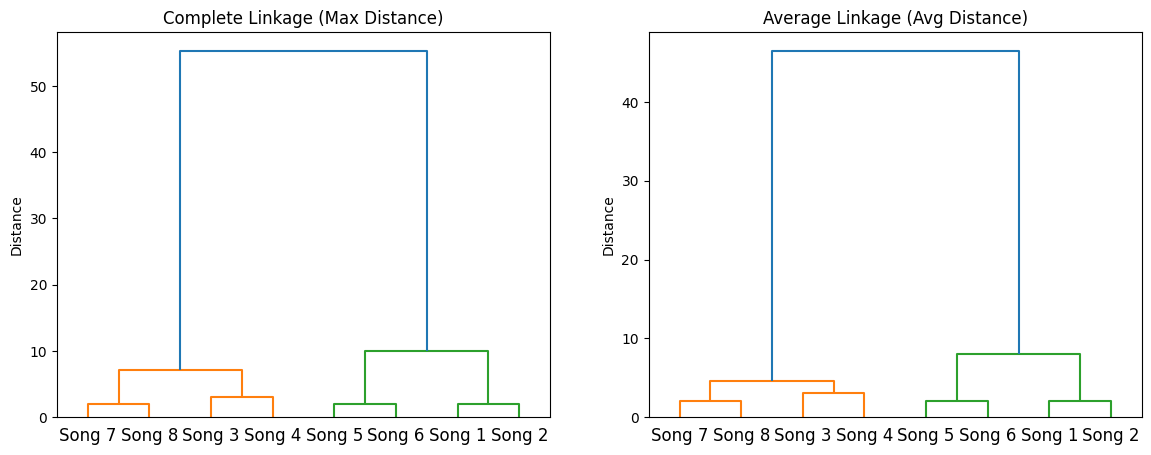

In [47]:
linked_complete = linkage(songs, method='complete')
linked_average = linkage(songs, method='average')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dendrogram(linked_complete, labels=song_labels, ax=axes[0])
ax=axes[0].set_title("Complete Linkage (Max Distance)")
ax=axes[0].set_ylabel("Distance")

dendrogram(linked_average, labels=song_labels, ax=axes[1])
ax=axes[1].set_title("Average Linkage (Avg Distance)")
ax=axes[1].set_ylabel("Distance")

plt.show()

* 4. Write a function that, given two points (x1, y1) and (x2, y2), returns both their Euclidean and Manhattan distances. Test it on three pairs of coordinates from your dataset.

In [48]:
def calculate_distances(p1, p2):
    p1 = np.array(p1)
    p2 = np.array(p2)
    
    euclidean = np.sqrt(np.sum((p1 - p2)**2))
    manhattan = np.sum(np.abs(p1 - p2))
    
    return euclidean, manhattan

In [49]:
point_A = orders[0]  
point_B = orders[1]  
point_C = orders[3]  

In [50]:
euc_AB, man_AB = calculate_distances(point_A, point_B)
euc_AC, man_AC = calculate_distances(point_A, point_C)
euc_BC, man_BC = calculate_distances(point_B, point_C)

In [51]:
print(f"Order 1 to Order 2 Euclidean: {euc_AB}, Manhattan: {man_AB}")
print(f"Order 1 to Order 4 Euclidean: {euc_AC}, Manhattan: {man_AC}")
print(f"Order 2 to Order 4 Euclidean: {euc_BC}, Manhattan: {man_BC}")

Order 1 to Order 2 Euclidean: 5.024937810560445, Manhattan: 5.5
Order 1 to Order 4 Euclidean: 5.0990195135927845, Manhattan: 6.0
Order 2 to Order 4 Euclidean: 10.111874208078342, Manhattan: 11.5


* 5. Imagine you are building a 'similar movies' feature for a movie app. Briefly describe which linkage method (single, complete, average, or Ward) you would choose for grouping movies by user ratings and why.

**Linkage Method Choice:** Ward's Method

**Why?** It minimizes variance *inside* each cluster. This creates tight, compact, and evenly sized groups of movies that have highly consistent rating patterns.

**Why not the others?**

* **Single:** Suffers from "chaining"—one overlapping rating can accidentally merge Horror and Rom-Coms into a giant, useless blob.
* **Complete:** Too sensitive to outliers—a single rogue 1-star rating can completely kick a movie out of its rightful cluster.
* **Average:** Easily biased by uneven cluster sizes, making it less reliable for messy user data.